# Project Scope Recap

### Dataset

**Primary Dataset:** PIPr — The PIPr Dataset of Public Infrastructure as Code Programs [Zenodo Record 10173400](https://zenodo.org/records/10173400)
- **Scale:** 37,712 real-world IaC programs across 23,428 GitHub repositories
- **Solutions:** AWS CDK (23,940 programs), Pulumi (12,945), CDKTF (827)
- **Languages:** TypeScript, Python, Go, C#, Java, JavaScript, YAML
- **Structure:** Three metadata CSVs (programs, repositories, testing-files) + 58 GB redistributable source code
- **Provenance:** Real GitHub repositories — not curated, not synthetic

### Key EDA Findings

- **Dominance skew:** AWS CDK accounts for 63% of programs; TypeScript is the dominant language within CDK — naive pattern mining will reflect CDK/TypeScript conventions unless explicitly controlled
- **Long-tail distributions:** 90.3% of repos contain a single program; forks and stars are heavily right-skewed (median forks = 0) — the dataset is dominated by small, independent projects
- **Testing gap:** CDK programs have a 38.2% test adoption rate vs. 1.3% for Pulumi and 14.6% for CDKTF — testing presence is a viable proxy for production-grade quality
- **Missing metadata:** 66% of programs lack names or descriptions — text mining on documentation is not viable at scale; structural analysis of the code itself is the primary signal source
- **Temporal concentration:** Repository creation is concentrated in 2018–2022, with exponential growth peaking around 2021 — temporal effects must be accounted for in any longitudinal analysis

### Project Goal

The overarching goal of this project is to produce a curated, structurally diverse dataset suitable for fine-tuning LLMs on natural language → IaC generation tasks — i.e., given a plain-English description of infrastructure needs, an LLM should produce correct, idiomatic IaC code.

**Data mining is the primary methodology.** The PIPr dataset encodes 37,712 real architectural decisions made by engineers across three IaC ecosystems. Before any fine-tuning dataset can be assembled responsibly, we need to understand what patterns exist, how quality varies, what archetypes are represented, and where coverage gaps lie. These are fundamentally data mining questions.

- **Course techniques applied:** Frequent pattern mining, clustering, anomaly detection, text mining
- **External techniques applied:** Graph Neural Networks (GNNs) for dependency graph classification

# Additional EDAs

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Reload PIPr metadata ---
# Same paths as CP1 — update if your directory structure differs
programs = pd.read_csv('./Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/data/metadata/programs.csv')
repos    = pd.read_csv('./Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/data/metadata/repositories.csv')
testing  = pd.read_csv('./Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/data/metadata/testing-files.csv')

# --- Recreate derived columns used in CP1 ---
programs['has_tests'] = programs['testing'].notna() & (programs['testing'] != '[]')
repos['created_dt']   = pd.to_datetime(repos['created'], errors='coerce')

print(f"Programs: {len(programs):,}")
print(f"Repos:    {len(repos):,}")
print(f"Testing:  {len(testing):,}")

Programs: 37,712
Repos:    23,428
Testing:  18,384


Repos with 2+ distinct solution-language pairs: 491
(out of 21,445 total repos — 2.3%)

Total unique co-occurring pairs found: 80
Total repo baskets (denominator for support): 21,445


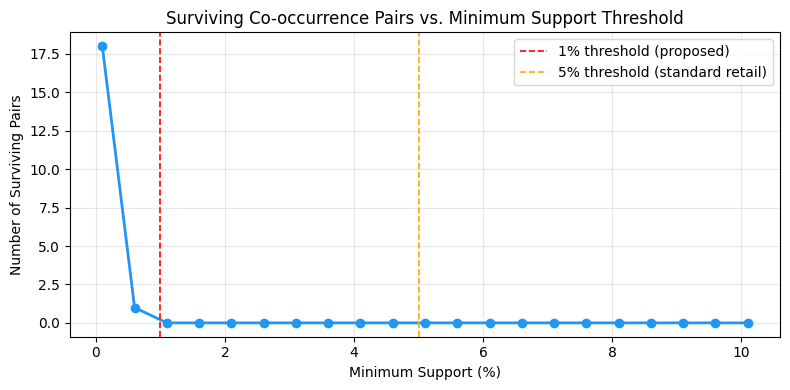


Top 10 co-occurring pairs by raw count:
Pair                                                          Count   Support
------------------------------------------------------------------------------
("('Pulumi', 'python')", "('Pulumi', 'typescript')")            153     0.71%
("('Pulumi', 'go')", "('Pulumi', 'typescript')")                112     0.52%
("('AWS CDK', 'python')", "('AWS CDK', 'typescript')")          104     0.48%
("('Pulumi', 'go')", "('Pulumi', 'python')")                     89     0.42%
("('Pulumi', 'csharp')", "('Pulumi', 'typescript')")             87     0.41%
("('Pulumi', 'csharp')", "('Pulumi', 'python')")                 80     0.37%
("('Pulumi', 'csharp')", "('Pulumi', 'go')")                     67     0.31%
("('AWS CDK', 'javascript')", "('AWS CDK', 'typescript')")       63     0.29%
("('AWS CDK', 'java')", "('AWS CDK', 'typescript')")             53     0.25%
("('AWS CDK', 'java')", "('AWS CDK', 'python')")                 39     0.18%


In [4]:
# EDA 1: Resource Co-occurrence Sparsity & Support Threshold Sweep

from itertools import combinations
from collections import Counter

# --- Build transaction baskets: one per repository ---
# Each basket = set of (solution, language) pairs seen across that repo's programs
repo_baskets = (
    programs
    .groupby('repository')
    .apply(lambda df: list(set(zip(df['solution'], df['language']))))
    .reset_index()
    .rename(columns={0: 'basket'})
)

# Filter to multi-program repos only (single-item baskets produce no pairs)
multi_baskets = repo_baskets[repo_baskets['basket'].apply(len) > 1]
print(f"Repos with 2+ distinct solution-language pairs: {len(multi_baskets):,}")
print(f"(out of {len(repo_baskets):,} total repos — "
      f"{len(multi_baskets)/len(repo_baskets)*100:.1f}%)")

# --- Count co-occurring pairs ---
pair_counts = Counter()
for basket in multi_baskets['basket']:
    for pair in combinations(sorted(str(x) for x in basket), 2):
        pair_counts[pair] += 1

total_baskets = len(repo_baskets)
print(f"\nTotal unique co-occurring pairs found: {len(pair_counts):,}")
print(f"Total repo baskets (denominator for support): {total_baskets:,}")

# --- Support threshold sweep ---
thresholds = np.arange(0.001, 0.105, 0.005)  # 0.1% to 10% in 0.5% steps
surviving_pairs = [
    sum(1 for c in pair_counts.values() if c / total_baskets >= t)
    for t in thresholds
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds * 100, surviving_pairs, marker='o', linewidth=2, color='#2196F3')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.2, label='1% threshold (proposed)')
ax.axvline(x=5.0, color='orange', linestyle='--', linewidth=1.2, label='5% threshold (standard retail)')
ax.set_title('Surviving Co-occurrence Pairs vs. Minimum Support Threshold')
ax.set_xlabel('Minimum Support (%)')
ax.set_ylabel('Number of Surviving Pairs')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Print top 10 pairs by support for interpretability check ---
top_pairs = sorted(pair_counts.items(), key=lambda x: -x[1])[:10]
print("\nTop 10 co-occurring pairs by raw count:")
print(f"{'Pair':<60} {'Count':>6}  {'Support':>8}")
print("-" * 78)
for pair, count in top_pairs:
    print(f"{str(pair):<60} {count:>6}  {count/total_baskets*100:>7.2f}%")

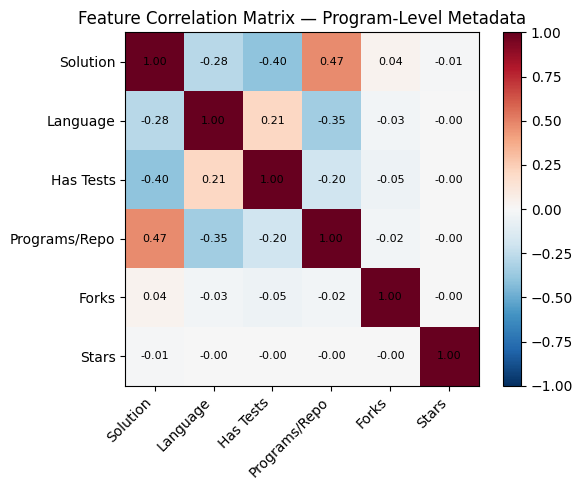

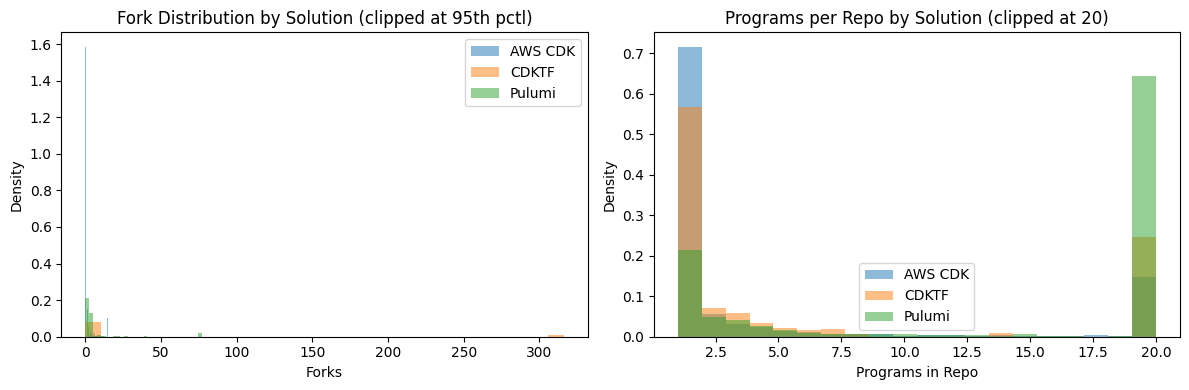

Testing adoption and feature summary by solution:
has_tests  Untested  Tested  pct_tested
solution                               
AWS CDK       14788    9152        38.2
CDKTF           706     121        14.6
Pulumi        12783     162         1.3


In [10]:
# EDA 2: Solution × Quality Feature Distributions

from sklearn.preprocessing import LabelEncoder

# --- Merge programs with repo-level signals ---
programs_per_repo = programs.groupby('repository').size().rename('programs_in_repo')
repo_features = repos[['ID', 'forks', 'fork']].rename(columns={'ID': 'repository'})

features = (
    programs
    .merge(programs_per_repo, on='repository')
    .merge(repo_features, on='repository', how='left')
)

# Encode categorical fields numerically for correlation analysis
le_solution  = LabelEncoder()
le_language  = LabelEncoder()
features['solution_enc']  = le_solution.fit_transform(features['solution'])
features['language_enc']  = le_language.fit_transform(features['language'])
features['has_tests']     = features['testing'].notna() & (features['testing'] != '[]')
features['has_tests_int'] = features['has_tests'].astype(int)

numeric_cols = ['solution_enc', 'language_enc', 'has_tests_int','programs_in_repo', 'forks', 'fork']
feature_matrix = features[numeric_cols].fillna(0)

# --- Correlation matrix ---
fig, ax = plt.subplots(figsize=(7, 5))
corr = feature_matrix.corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
labels = ['Solution', 'Language', 'Has Tests', 'Programs/Repo', 'Forks', 'Stars']
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Feature Correlation Matrix — Program-Level Metadata')
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color='black')
plt.tight_layout()
plt.show()

# --- Distribution of forks and programs-per-repo stratified by solution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for solution, grp in features.groupby('solution'):
    axes[0].hist(
        grp['forks'].clip(upper=grp['forks'].quantile(0.95)),
        bins=30, alpha=0.5, label=solution, density=True
    )
axes[0].set_title('Fork Distribution by Solution (clipped at 95th pctl)')
axes[0].set_xlabel('Forks')
axes[0].set_ylabel('Density')
axes[0].legend()

for solution, grp in features.groupby('solution'):
    axes[1].hist(
        grp['programs_in_repo'].clip(upper=20),
        bins=20, alpha=0.5, label=solution, density=True
    )
axes[1].set_title('Programs per Repo by Solution (clipped at 20)')
axes[1].set_xlabel('Programs in Repo')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Tested vs untested breakdown per solution ---
test_breakdown = (
    features
    .groupby(['solution', 'has_tests'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: 'Untested', True: 'Tested'})
)
test_breakdown['pct_tested'] = (
    test_breakdown['Tested'] / test_breakdown.sum(axis=1) * 100
).round(1)
print("Testing adoption and feature summary by solution:")
print(test_breakdown)

Programs with descriptions: 12,752 (33.8% of total)

Description availability by solution:
          with_desc  total   pct
solution                        
AWS CDK           0  23940   0.0
CDKTF             0    827   0.0
Pulumi        12752  12945  98.5


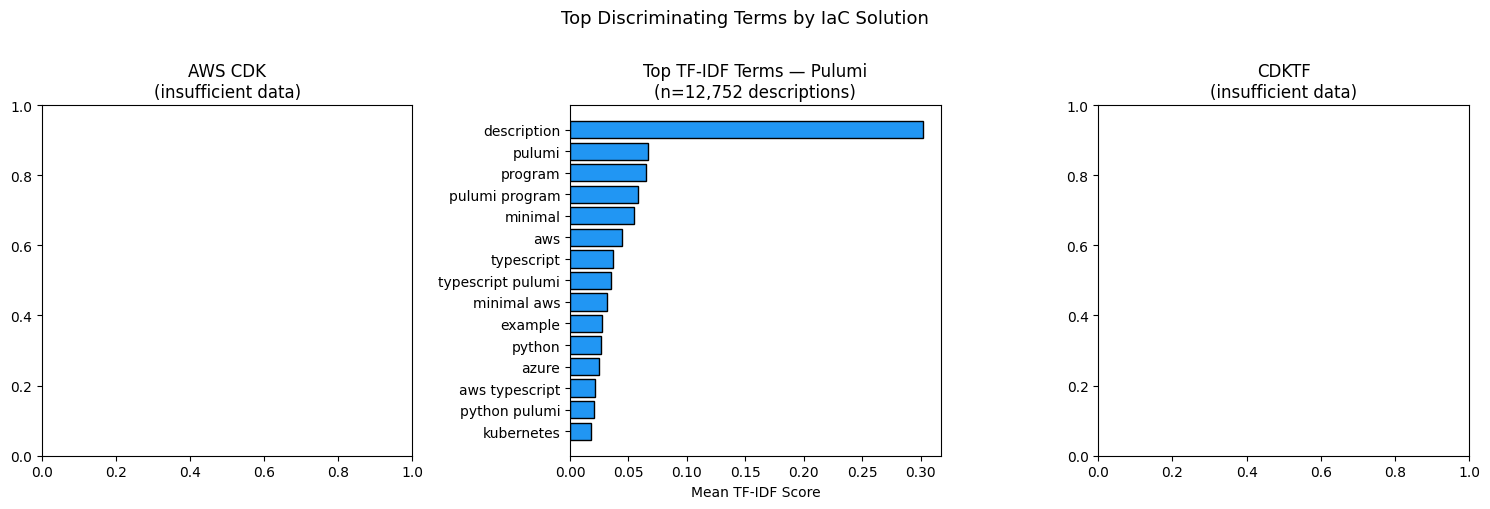


Vocabulary overlap (top-15 TF-IDF terms):


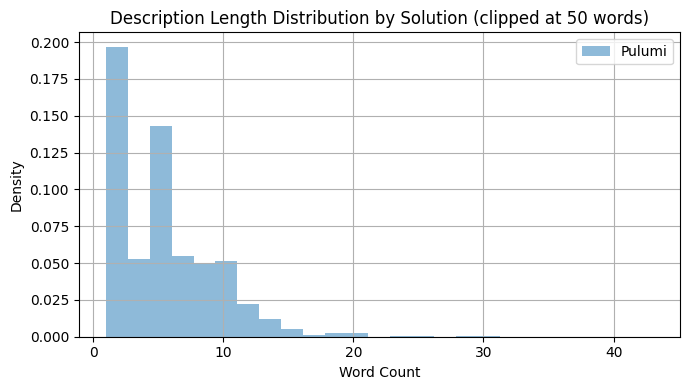


Median description length by solution:
solution
Pulumi    6.0
Name: desc_len, dtype: float64


In [ ]:
# EDA 3: Description Text Analysis

from sklearn.feature_extraction.text import TfidfVectorizer

# --- Isolate programs with non-empty descriptions ---
has_desc = programs[programs['description'].notna() & (programs['description'].str.strip() != '')].copy()

print(f"Programs with descriptions: {len(has_desc):,} "
      f"({len(has_desc)/len(programs)*100:.1f}% of total)")
print()
print("Description availability by solution:")
desc_by_solution = (
    programs
    .groupby('solution')['description']
    .apply(lambda x: x.notna().sum())
    .rename('with_desc')
    .to_frame()
)
desc_by_solution['total']    = programs.groupby('solution').size()
desc_by_solution['pct']      = (desc_by_solution['with_desc'] / desc_by_solution['total'] * 100).round(1)
print(desc_by_solution)

# --- TF-IDF per solution: top discriminating terms ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
solutions = ['AWS CDK', 'Pulumi', 'CDKTF']

solution_vocab = {}
for ax, sol in zip(axes, solutions):
    corpus = has_desc[has_desc['solution'] == sol]['description'].tolist()
    if len(corpus) < 10:
        ax.set_title(f'{sol}\n(insufficient data)')
        continue

    tfidf = TfidfVectorizer(
        max_features=500,
        stop_words='english',
        min_df=2,           # term must appear in at least 2 docs
        ngram_range=(1, 2)  # unigrams and bigrams
    )
    tfidf.fit_transform(corpus)
    mean_scores = np.asarray(
        tfidf.fit_transform(corpus).mean(axis=0)
    ).flatten()
    top_idx     = mean_scores.argsort()[-15:][::-1]
    top_terms   = [tfidf.get_feature_names_out()[i] for i in top_idx]
    top_scores  = mean_scores[top_idx]

    solution_vocab[sol] = set(top_terms)

    ax.barh(top_terms[::-1], top_scores[::-1], color='#2196F3', edgecolor='black')
    ax.set_title(f'Top TF-IDF Terms — {sol}\n(n={len(corpus):,} descriptions)')
    ax.set_xlabel('Mean TF-IDF Score')

plt.suptitle('Top Discriminating Terms by IaC Solution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Vocabulary overlap between solutions ---
print("\nVocabulary overlap (top-15 TF-IDF terms):")
sols = [s for s in solutions if s in solution_vocab]
for i, s1 in enumerate(sols):
    for s2 in sols[i+1:]:
        overlap = solution_vocab[s1] & solution_vocab[s2]
        print(f"  {s1} ∩ {s2}: {len(overlap)} shared terms — {sorted(overlap)}")

# --- Description length distribution by solution ---
has_desc['desc_len'] = has_desc['description'].str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 4))
for sol, grp in has_desc.groupby('solution'):
    grp['desc_len'].clip(upper=50).hist(bins=25, alpha=0.5, label=sol, density=True, ax=ax)
ax.set_title('Description Length Distribution by Solution (clipped at 50 words)')
ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMedian description length by solution:")
print(has_desc.groupby('solution')['desc_len'].median().round(1))

### Additional EDA — Findings Summary

**From EDA #1 (support sweep):** Co-occurrence signal in the metadata is extremely sparse —
only 2.3% of repos contain programs from more than one solution-language combination, producing
just 80 unique pairs across 21,445 repos. Only 18 pairs survive at 1% support; essentially none
survive at 5%. This confirms two things: (1) the solution-language proxy is too coarse — real
resource co-occurrence mining must operate on parsed source files, not metadata alone; (2) the
1% threshold is the correct lower bound, and standard retail thresholds would eliminate all signal.

**From EDA #2 (feature distributions):** Clear clustering signals exist. Solution encodes strongly
with Programs/Repo (r=0.47) and negatively with Has Tests (r=-0.40) and Language (r=-0.28) —
meaning solution type is not independent of quality or structure. Pulumi repos show a distinct
long-tail in the programs-per-repo distribution (the spike at 20+ is entirely Pulumi), while CDK
and CDKTF are tightly concentrated at 1–2 programs per repo. Fork distributions are
indistinguishable across solutions — forks carry no solution-discriminating signal and can be
dropped as a clustering feature.

**From EDA #3 (description text):** A critical structural finding — descriptions exist almost
exclusively in Pulumi (98.5% coverage, n=12,752) and are entirely absent from AWS CDK and
CDKTF (0.0% each). This means text mining cannot serve as a cross-solution analysis technique.
The descriptions that do exist are short (median 6 words), noisy, and dominated by boilerplate
("description", "pulumi program", "minimal aws").

# Research Question Definitions

## RQ1 — What frequent resource co-occurrence patterns define canonical IaC architectures, and how do these patterns differ across AWS CDK, Pulumi, and CDKTF?


**Motivation:** The support threshold sweep (EDA #1) confirmed that co-occurrence signal exists at low thresholds — 18 pairs survive at 1% support, essentially none at 5%. This means standard retail-style thresholds would destroy all signal, and domain-appropriate thresholds are critical. The CDK dominance skew (63% of programs) means patterns must be mined per-solution, otherwise CDK conventions drown out Pulumi and CDKTF entirely.

**Task:** Frequent itemset mining. Each IaC program is a transaction; each distinct resource type instantiated in that program is an item. The goal is to discover which resource bundles consistently appear together — e.g., does Lambda almost always co-occur with IAMRole and CloudWatch across CDK programs? Do Pulumi programs show a different canonical bundle for the same architectural intent?

**Algorithms:**
- FP-Growth (course) — preferred over Apriori due to scalability on 37K programs without candidate generation overhead
- Association rule extraction post-mining to compute lift and confidence per rule

**Evaluation:**
- Support, confidence, and lift per rule
- Cross-solution pattern overlap: do CDK and Pulumi share the same canonical resource bundles, or do ecosystem conventions diverge?
- Qualitative interpretability: do high-lift rules correspond to recognized cloud architecture patterns?
- Baseline: top-5% support-only mining — to quantify what domain-relevant patterns get discarded at standard thresholds

**Non-triviality:** Simply counting the most common individual resource types (a frequency histogram) would tell us nothing about co-occurrence structure. Association rules capture conditional relationships — the fact that Lambda *given* IAMRole has lift >> 1 is architecturally meaningful in a way that marginal frequencies are not. Course techniques (FP-Growth + association rules) are precisely the right tool here; the non-triviality lies in the threshold calibration and the cross-solution comparison, not in needing an external method.

**Feasibility:** `mlxtend` provides a production-ready FP-Growth implementation that handles 37K transactions comfortably in memory. The main preprocessing step — parsing source files to extract resource type lists per program — is well-defined and scriptable using AST parsing for TypeScript/Python. A per-solution stratified run is straightforward to implement. The 1% minimum support threshold is confirmed feasible by the sweep results.

**Risks:** Source file parsing quality varies by language and IaC solution — TypeScript AST parsing for CDK is more mature than Go or C# parsing for Pulumi. Noisy or incomplete parses will produce sparse, unreliable baskets. Mitigation: start with a high-confidence subset (TypeScript CDK programs, ~14K programs) for the initial run, then expand. Parameter sensitivity around minimum confidence and lift thresholds will require a small sweep.



## RQ2 — What structural archetypes exist across IaC programs, and does their distribution reveal coverage gaps relevant to LLM fine-tuning?


**Motivation:** EDA #2 showed separable clustering signals in the metadata: solution type correlates with programs-per-repo (r=0.47) and testing adoption (r=-0.40), and Pulumi shows a distinct long-tail in program count while CDK and CDKTF concentrate at 1–2 programs per repo. With 66% of programs lacking descriptions, text-based clustering is not viable — structural features derived from the code itself are the primary signal source.

**Task:** Clustering on program-level structural features including resource count, resource type diversity, dependency depth, test presence, and solution type. The goal is to identify recurring architectural archetypes (e.g., "minimal single-service," "multi-tier web app," "data pipeline") and determine whether the 37K programs cover these archetypes uniformly or are skewed toward a narrow subset.

**Algorithms:**
- K-Means (course) — baseline clustering with k selected via elbow method and silhouette analysis
- DBSCAN (course) — to identify dense archetype cores and flag sparse/outlier programs as potential noise or highly specialized configurations

**Evaluation:**
- Silhouette score and Davies-Bouldin index for cluster quality
- Cluster composition inspection: are clusters solution-homogeneous (CDK programs cluster with CDK) or cross-solution (same archetype appears in all three)?
- Archetype coverage: are ML pipelines, data warehouses, or networking-heavy configurations absent or severely underrepresented?
- Baseline: trivial 3-cluster partition by solution label — clustering must produce meaningfully different groupings to justify the approach

**Non-triviality:** Simply partitioning programs by solution label gives a trivial 3-cluster result that reflects ecosystem provenance, not architectural content. The goal is to find cross-solution groupings where a CDK serverless pipeline and a Pulumi serverless pipeline land in the same cluster — revealing shared architectural intent despite different ecosystems. This requires thoughtful feature engineering and evaluation against a solution-label baseline to confirm that clustering adds genuine discriminative power.

**Feasibility:** K-Means and DBSCAN are available in scikit-learn and scale easily to 37K programs. The feature vector (resource count, resource type diversity, dependency depth, test presence, solution encoding) can be constructed from metadata and lightweight source parsing — no deep AST analysis required for most features. Silhouette and Davies-Bouldin scores provide objective cluster quality metrics that are straightforward to compute.

**Risks:** The feature vector quality is gated on source parsing — programs where parsing fails will have incomplete or zero-valued features, potentially creating a spurious "unparseable" cluster. Mitigation: flag and separately analyze unparseable programs rather than imputing. K-Means is also sensitive to the choice of k and feature scaling; a thorough elbow + silhouette sweep across k=2 to k=15 is needed before interpreting cluster semantics.

## RQ3 — Within Pulumi's description corpus, do textual patterns in program descriptions align with structural quality signals, and can description-derived features improve fine-tuning candidate selection?


**Motivation:** EDA #3 revealed that natural-language descriptions exist almost exclusively in Pulumi (98.5% coverage, ~12,700 programs) and are entirely absent for AWS CDK and CDKTF (0%). This makes cross-solution text mining infeasible, but creates a unique opportunity within Pulumi: the descriptions are the only naturally occurring NL→IaC prompt candidates in PIPr. Understanding whether these descriptions cluster meaningfully — and whether description-derived clusters align with structural quality markers like testing adoption — directly informs how many usable fine-tuning pairs can be extracted without synthetic augmentation. A known risk is description sparsity (median 6 words), so analysis will filter to descriptions above a minimum word-count floor.

**Task:** Text mining and topic modeling on Pulumi program descriptions, validated against structural quality labels from RQ2.

**Algorithms:**
- TF-IDF vectorization + K-Means clustering on description text (course)
- LDA topic modeling to surface latent infrastructure themes within the Pulumi corpus (course)

**Evaluation:**
- LDA topic coherence score to assess whether topics are semantically meaningful vs. noise
- Overlap between text-derived clusters and structure-derived clusters from RQ2 — if they agree, descriptions are a reliable proxy for architecture type; if not, they're too noisy to use as prompts
- Whether tested Pulumi programs cluster differently in description space than untested ones — this would validate descriptions as a prompt-quality signal for fine-tuning pair selection

**Non-triviality:** The descriptions are short (median 6 words) and noisy (dominated by boilerplate like "pulumi program," "minimal aws"). Naive TF-IDF on the full corpus would produce topics dominated by stop-phrase variants rather than semantic infrastructure themes. The non-trivial component is the preprocessing pipeline: filtering to descriptions above a word-count floor, removing IaC-specific boilerplate terms, and validating that resulting LDA topics are coherent rather than artifactual. Cross-validation between text-cluster structure and structure-cluster structure from RQ2 adds a second layer of non-trivial analysis.

**Feasibility:** scikit-learn provides TF-IDF, K-Means, and the gensim library provides LDA with coherence scoring — all well-documented and lightweight enough to run on the ~12K Pulumi description corpus without GPU resources. The primary feasibility risk is description quality rather than compute.

**Risks:** Short, boilerplate-heavy descriptions may not contain enough signal for LDA to converge on interpretable topics regardless of preprocessing. If coherence scores remain low after cleaning, RQ3 shifts from "descriptions are usable prompts" to "descriptions are not usable without augmentation" — which is still a meaningful and publishable negative result for the project goal.

## RQ4 — Does the dependency graph topology of an IaC program carry quality signal beyond resource identity alone?


**Motivation:** EDA #2 showed that testing presence is a strong quality proxy — CDK programs are 38.2% tested vs. 1.3% for Pulumi. IaC programs are inherently graph-structured: resources reference each other through explicit dependencies, forming directed graphs with meaningful topological properties (depth, branching factor, hub nodes). Whether graph topology discriminates production-grade programs from toy/tutorial code — beyond what a simple bag-of-resources feature vector can capture — is a question that course techniques cannot answer, since they discard relational structure entirely.

**Task:** Graph classification on resource dependency graphs. Nodes are resource types within a program; edges are explicit references between resources. The binary classification target is `has_tests` (True = production-grade, False = toy/tutorial).

**Algorithm:** GraphSAGE or GCN (external). The model learns graph-level representations by aggregating neighborhood information across the dependency structure.

**Evaluation:**
- F1-score and accuracy on the binary `has_tests` classification task
- Ablation against a bag-of-resources baseline (same features, no edges) — this isolates whether topology adds discriminative signal beyond node identity alone
- Feature importance analysis: which structural properties (depth, branching factor, presence of hub resource nodes) are most predictive of quality?

**Non-triviality:** A bag-of-resources classifier (e.g., logistic regression on resource type counts) could predict `has_tests` using node identity alone. The non-trivial question is whether graph *topology* — the edges, not just the nodes — adds discriminative signal on top of that. Course techniques (K-Means, DBSCAN) operate on fixed-length feature vectors and cannot natively represent variable-size graphs with relational structure. GNNs are the appropriate external method because they learn representations that explicitly encode neighborhood structure.

**Feasibility:** PyTorch Geometric provides GraphSAGE and GCN implementations with well-documented graph classification examples. The main bottleneck is dependency graph construction from source files, which requires AST-level parsing. A stratified sample of ~500–1,000 parseable programs per solution (targeting TypeScript CDK and Python Pulumi first) is a realistic scope for CP3. Binary classification with a bag-of-resources ablation baseline is straightforward to implement and evaluate.

**Risks:** Graph construction quality is the primary risk — incorrectly parsed dependency edges will produce structurally incorrect graphs, and the GNN will learn noise. A second risk is class imbalance: Pulumi programs are only 1.3% tested, so the training set for Pulumi will be heavily skewed toward the negative class. Mitigation: stratified sampling and class-weighted loss during training. Computational cost is manageable at the ~1,500-program sample scale even on CPU.

## RQ-to-Method Mapping

| RQ | Research Question (abbreviated) | Task | Algorithm(s) | Course / External | Primary Metric |
|---|---|---|---|---|---|
| RQ1 | Frequent resource co-occurrence patterns across solutions | Frequent itemset mining | FP-Growth + association rules | **Course** | Support, lift, confidence |
| RQ2 | Architectural archetypes and coverage gaps | Clustering | K-Means, DBSCAN | **Course** | Silhouette score, archetype distribution |
| RQ3 | Description text alignment with quality signals (Pulumi) | Text mining + topic modeling | TF-IDF, LDA, K-Means | **Course** | Topic coherence, cluster-quality overlap |
| RQ4 | Graph topology as a quality signal | Graph classification | GraphSAGE / GCN | **External** | F1 vs. bag-of-resources baseline |